Ecological Site Data:
     Site  Temperature  Humidity  Mammals  Birds  Reptiles
0  Site_1         28.5        65       12     15         8
1  Site_2         22.3        78        8     18         5
2  Site_3         18.7        85        5     22         2
3  Site_4         25.4        70        9     17         7
4  Site_5         15.6        92        3     25         1

Basic Statistics:
       Temperature   Humidity    Mammals      Birds  Reptiles
count     5.000000   5.000000   5.000000   5.000000   5.00000
mean     22.100000  78.000000   7.400000  19.400000   4.60000
std       5.140525  10.931606   3.507136   4.037326   3.04959
min      15.600000  65.000000   3.000000  15.000000   1.00000
25%      18.700000  70.000000   5.000000  17.000000   2.00000
50%      22.300000  78.000000   8.000000  18.000000   5.00000
75%      25.400000  85.000000   9.000000  22.000000   7.00000
max      28.500000  92.000000  12.000000  25.000000   8.00000

Correlation Matrix:
             Temperature  

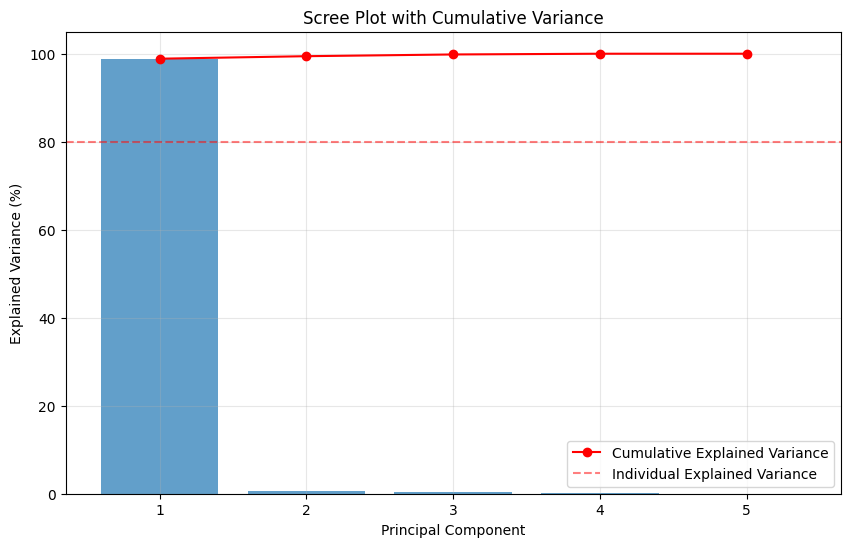

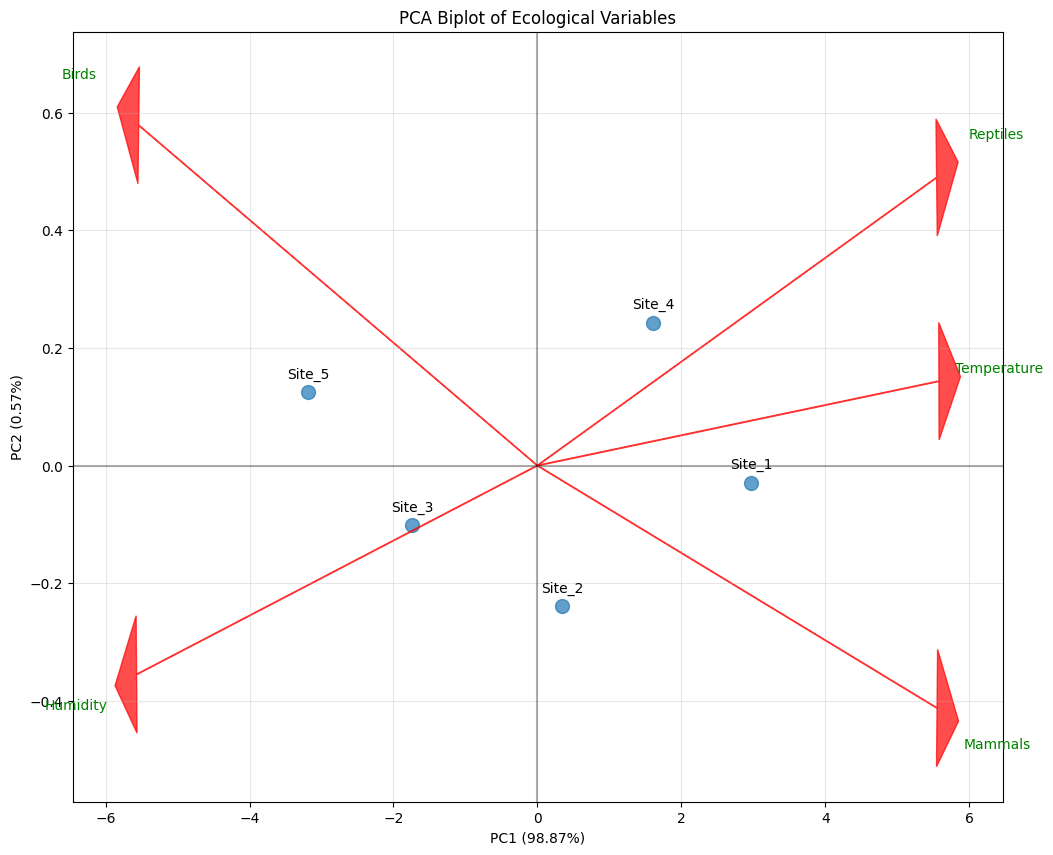

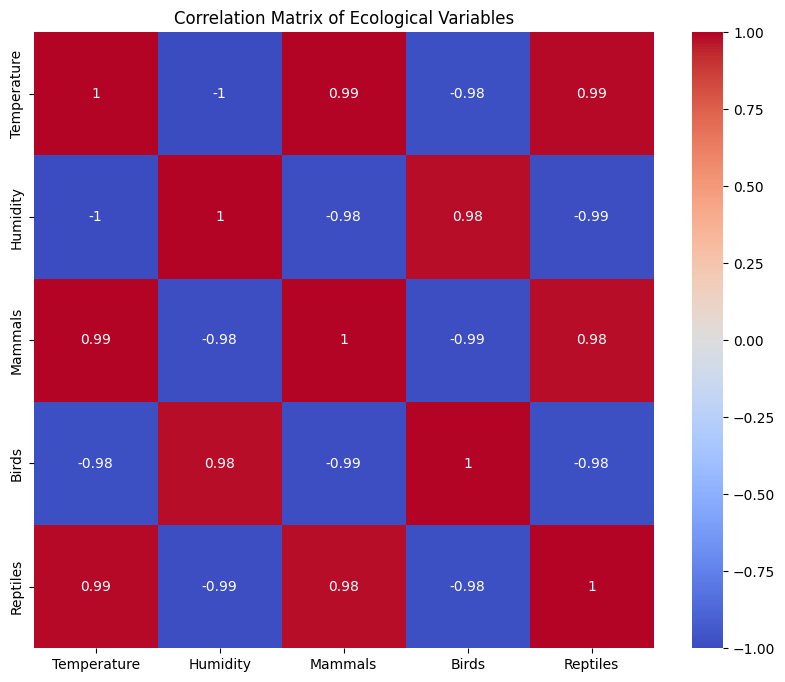

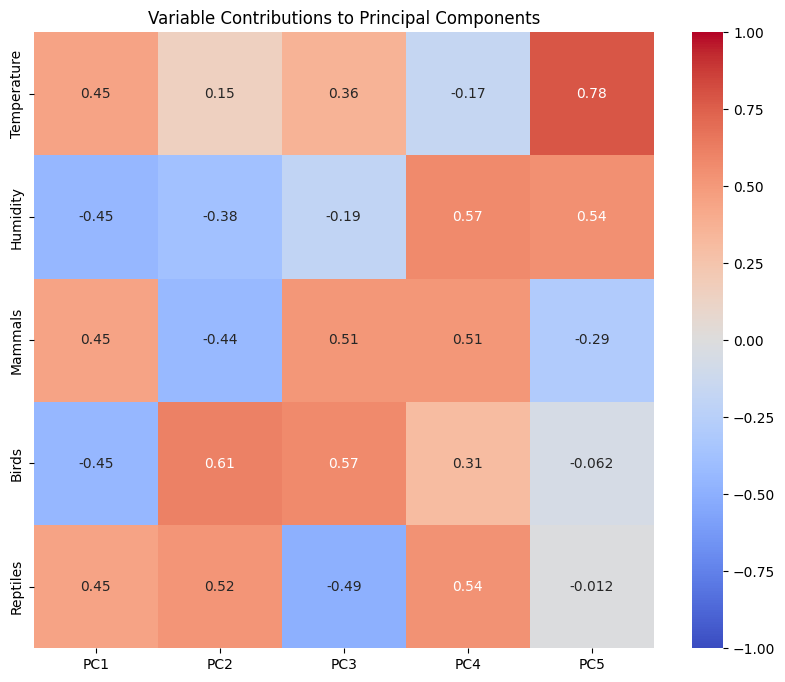

/tmp/ipykernel_2407/1188987573.py:180: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scaled_values = np.append(scaled_values, scaled_values[0])


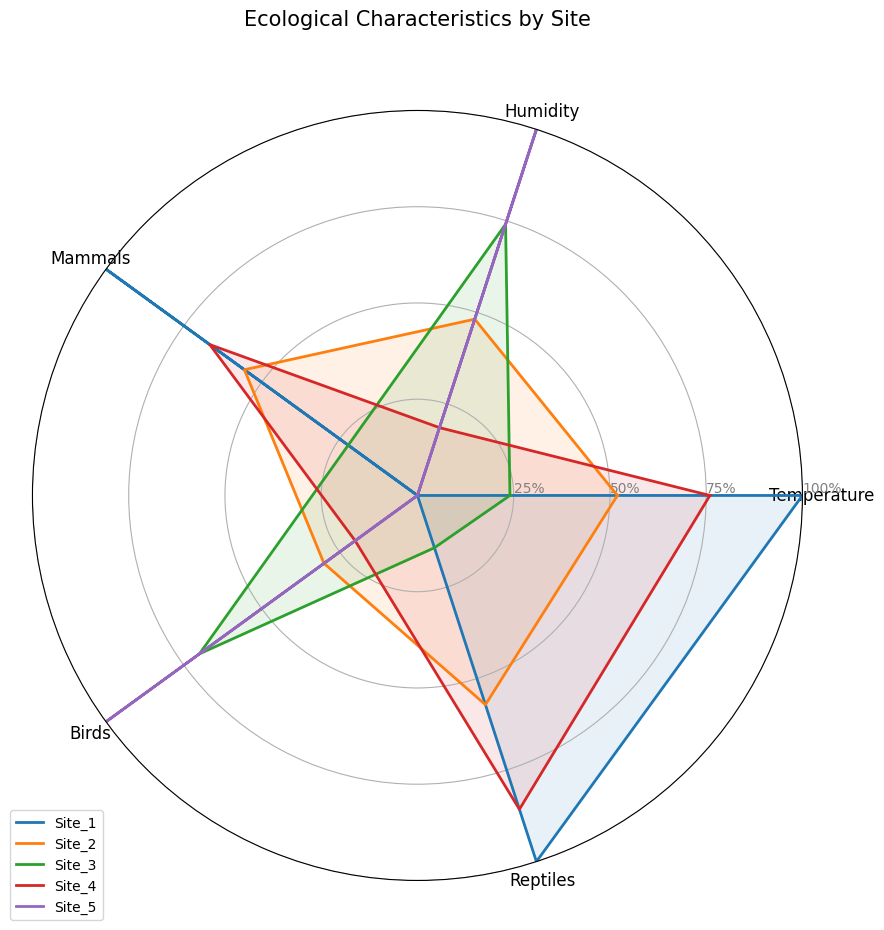

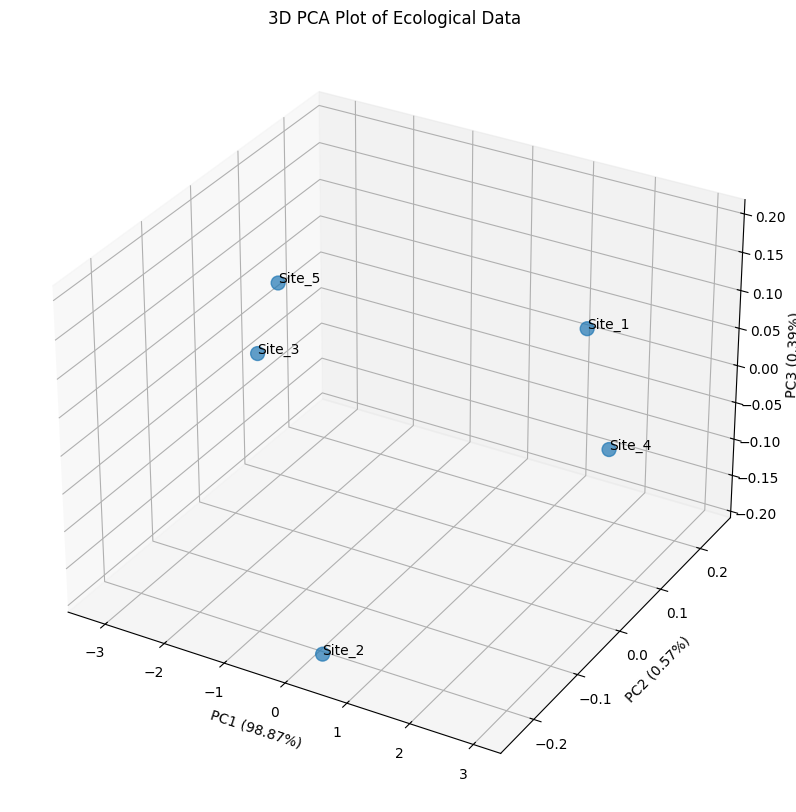


Ecological Site Interpretation Based on PCA:
Site_1: This is a warm and species-rich site with lower humidity with fewer birds.
Site_2: This is a warm and species-rich site with lower humidity with fewer birds.
Site_3: This is a cool and species-poor site with lower humidity with fewer birds.
Site_4: This is a warm and species-rich site with high humidity with more birds.
Site_5: This is a cool and species-poor site with high humidity with more birds.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Create a small dataset with ecological variables for 5 sites
n_sites = 5

# Create site names
sites = [f"Site_{i+1}" for i in range(n_sites)]

# Generate ecological data with correlations
# Temperature (°C)
temperature = np.array([28.5, 22.3, 18.7, 25.4, 15.6])

# Humidity (%)
# Generally, temperature and humidity have an inverse relationship
humidity = np.array([65, 78, 85, 70, 92])

# Animal counts (three different species)
mammals = np.array([12, 8, 5, 9, 3])  # More mammals in warmer areas
birds = np.array([15, 18, 22, 17, 25])  # More birds in areas with higher humidity
reptiles = np.array([8, 5, 2, 7, 1])  # More reptiles in warmer areas

# Create pandas DataFrame
eco_data = pd.DataFrame({
    'Site': sites,
    'Temperature': temperature,
    'Humidity': humidity,
    'Mammals': mammals,
    'Birds': birds,
    'Reptiles': reptiles
})

# Display the dataset
print("Ecological Site Data:")
print(eco_data)

# Basic statistics
print("\nBasic Statistics:")
print(eco_data.iloc[:, 1:].describe())

# Correlation matrix
print("\nCorrelation Matrix:")
correlation_matrix = eco_data.iloc[:, 1:].corr()
print(correlation_matrix)

# Standardize the data
X = eco_data.iloc[:, 1:].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(X_scaled)

# Create DataFrame with PCA results
pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(X.shape[1])])
pca_df['Site'] = sites

# Explained variance
explained_variance = pca.explained_variance_ratio_ * 100
print("\nExplained Variance by Principal Components:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.2f}%")

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)
print("\nCumulative Explained Variance:")
for i, var in enumerate(cumulative_variance):
    print(f"First {i+1} PC(s): {var:.2f}%")

# Get the loadings (correlation between variables and principal components)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(X.shape[1])])
loadings_df['Variable'] = eco_data.columns[1:]

print("\nVariable Loadings:")
print(loadings_df)

# VISUALIZATIONS

# 1. Scree plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7)
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, 'ro-')
plt.axhline(y=80, color='r', linestyle='--', alpha=0.5)  # Typical threshold line
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot with Cumulative Variance')
plt.xticks(range(1, len(explained_variance) + 1))
plt.legend(['Cumulative Explained Variance', 'Individual Explained Variance'])
plt.grid(True, alpha=0.3)
plt.show()

# 2. Biplot of first two principal components
plt.figure(figsize=(12, 10))

# Plot the observations
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=100, alpha=0.7)

# Add site labels
for i, site in enumerate(sites):
    plt.annotate(site, (pca_result[i, 0], pca_result[i, 1]),
                 textcoords="offset points", xytext=(0,10), ha='center')

# Plot vectors for variables
feature_names = eco_data.columns[1:]
scaling_factor = 5  # Adjust this to scale the arrows appropriately
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0,
              loadings[i, 0] * scaling_factor,
              loadings[i, 1] * scaling_factor,
              color='r', alpha=0.7, head_width=0.2)
    plt.text(loadings[i, 0] * scaling_factor * 1.15,
             loadings[i, 1] * scaling_factor * 1.15,
             feature, color='g', ha='center', va='center')

plt.xlabel(f'PC1 ({explained_variance[0]:.2f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2f}%)')
plt.title('PCA Biplot of Ecological Variables')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.show()

# 3. Heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Ecological Variables')
plt.show()

# 4. Heatmap of variable contributions to principal components
loadings_heatmap = pd.DataFrame(pca.components_.T,
                              columns=[f'PC{i+1}' for i in range(X.shape[1])],
                              index=feature_names)
plt.figure(figsize=(10, 8))
sns.heatmap(loadings_heatmap, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Variable Contributions to Principal Components')
plt.show()

# 5. Radar/Spider chart to visualize site characteristics
from matplotlib.path import Path
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

def radar_chart(df, categories, title):
    # Number of variables
    N = len(categories)

    # What will be the angle of each axis in the plot (divide the plot / number of variables)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop

    # Initialize the figure
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories, size=12)

    # Draw the y axis labels (0-100%)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75, 1], ["25%", "50%", "75%", "100%"], color="grey", size=10)
    plt.ylim(0, 1)

    # Plot each site
    for i, site in enumerate(df['Site']):
        values = df.iloc[i, 1:].values  # Get values for this site
        # Scale to 0-1 range for each variable
        min_vals = df.iloc[:, 1:].min()
        max_vals = df.iloc[:, 1:].max()
        scaled_values = (values - min_vals) / (max_vals - min_vals)

        # Close the loop
        scaled_values = np.append(scaled_values, scaled_values[0])

        # Plot values
        ax.plot(angles, scaled_values, linewidth=2, linestyle='solid', label=site)
        ax.fill(angles, scaled_values, alpha=0.1)

    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title(title, size=15, y=1.1)

    return fig, ax

# Create radar chart
radar_chart(eco_data, eco_data.columns[1:], 'Ecological Characteristics by Site')
plt.show()

# 6. 3D PCA plot (first three components)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the observations
ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], s=100, alpha=0.7)

# Add site labels
for i, site in enumerate(sites):
    ax.text(pca_result[i, 0], pca_result[i, 1], pca_result[i, 2], site)

ax.set_xlabel(f'PC1 ({explained_variance[0]:.2f}%)')
ax.set_ylabel(f'PC2 ({explained_variance[1]:.2f}%)')
ax.set_zlabel(f'PC3 ({explained_variance[2]:.2f}%)')
ax.set_title('3D PCA Plot of Ecological Data')
plt.show()

# 7. Create a simple ecological interpretation of sites based on PCA
print("\nEcological Site Interpretation Based on PCA:")
for i, site in enumerate(sites):
    pc1_contrib = pca_result[i, 0]
    pc2_contrib = pca_result[i, 1]

    # Interpret PC1
    pc1_interp = "warm and species-rich" if pc1_contrib > 0 else "cool and species-poor"
    # Interpret PC2
    pc2_interp = "high humidity with more birds" if pc2_contrib > 0 else "lower humidity with fewer birds"

    print(f"{site}: This is a {pc1_interp} site with {pc2_interp}.")

In [ ]:
 pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.4 MB/s eta 0:00:00


Performing Ordinary Kriging...
Performing Universal Kriging...


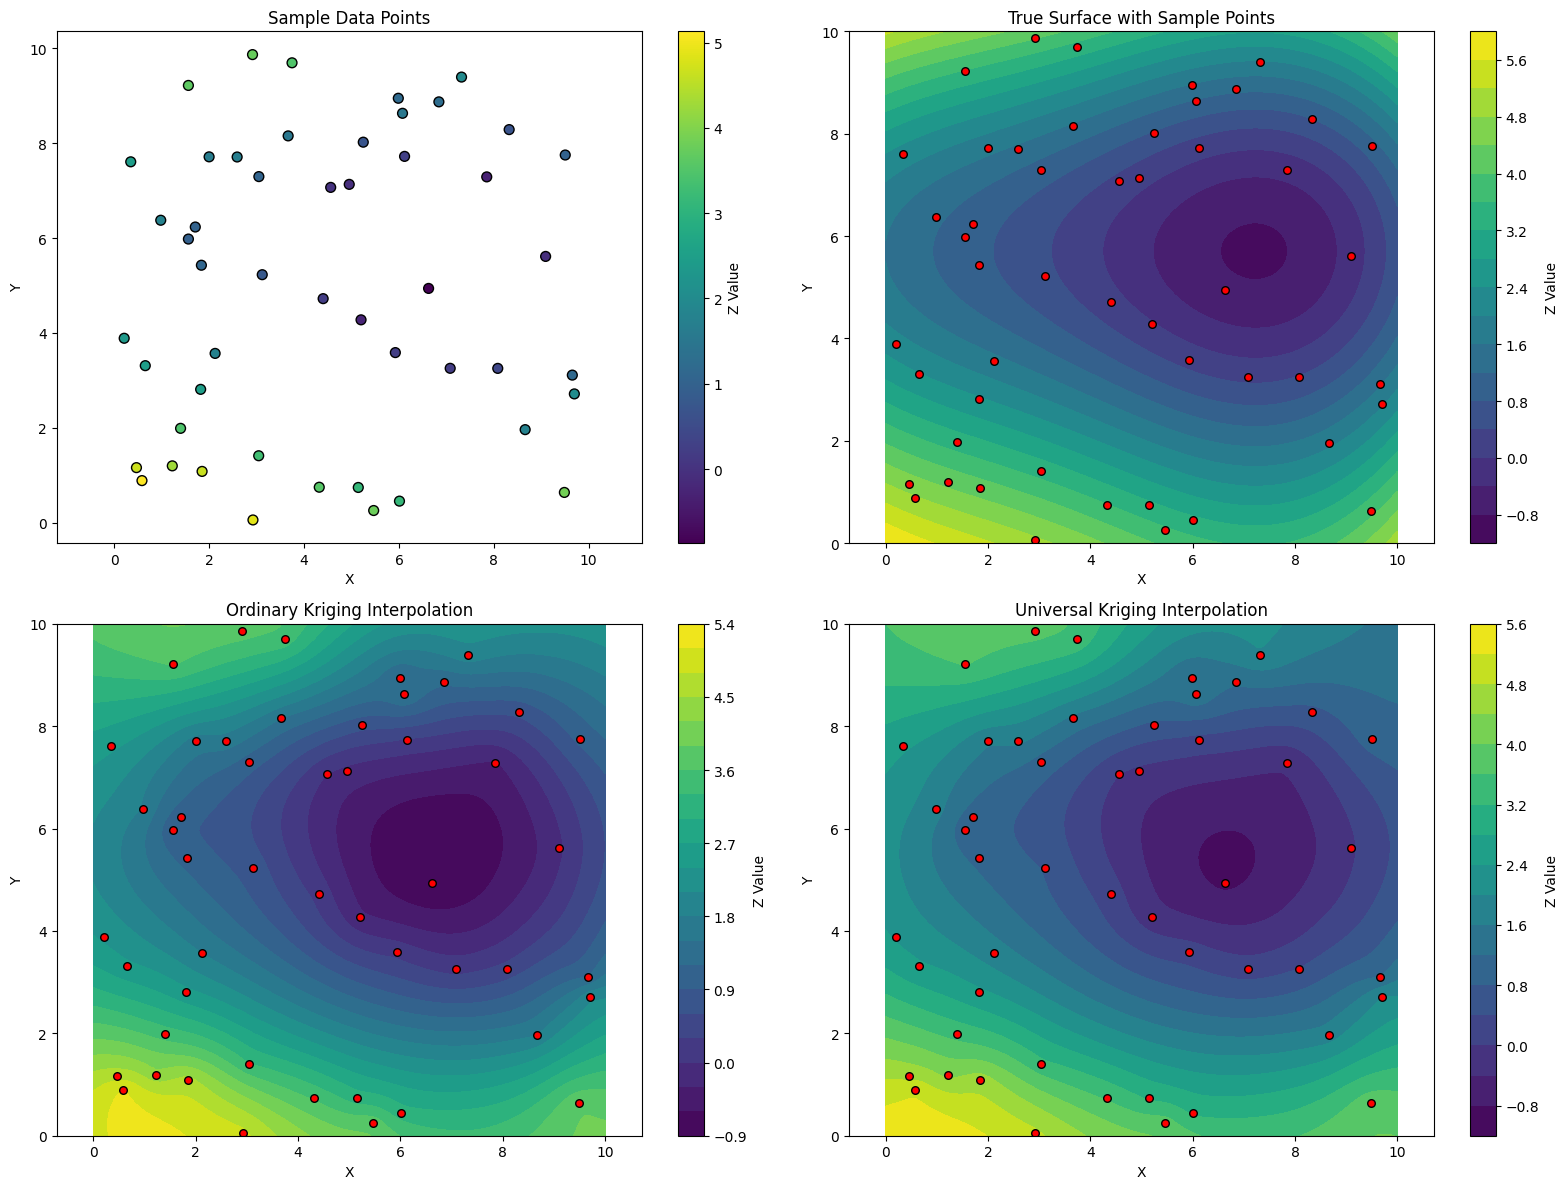

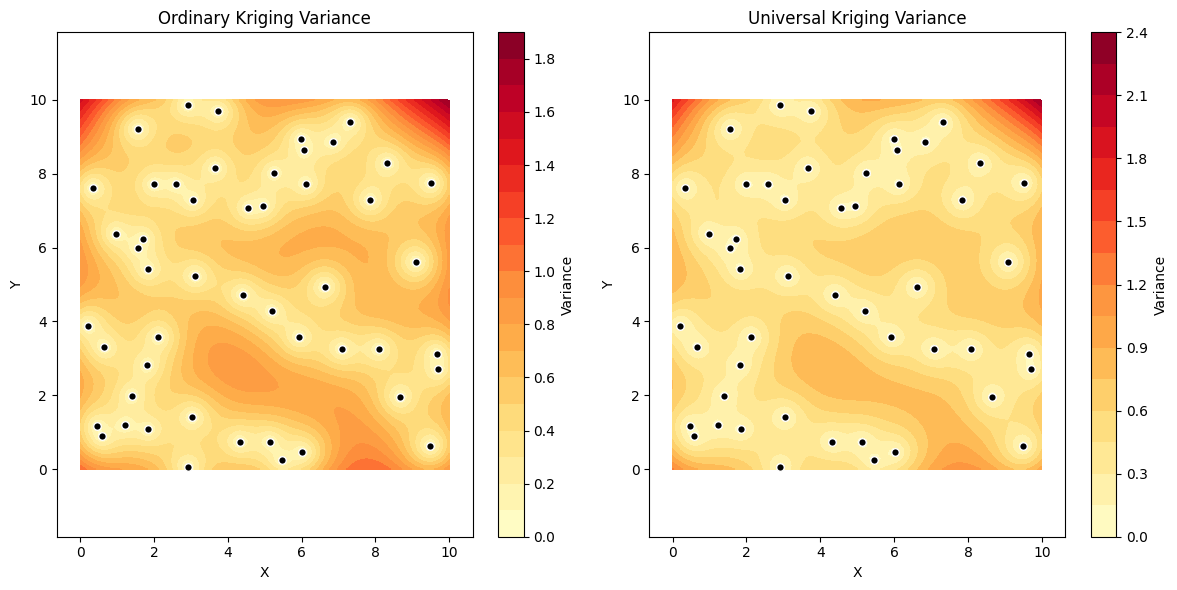

Mean Squared Error (Ordinary Kriging): 0.0632
Mean Squared Error (Universal Kriging): 0.0941


In [ ]:
# Ordinary Kriging Example in Python
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging
from matplotlib import cm

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample data
# Coordinates of sample points
n_points = 50
x = np.random.rand(n_points) * 10
y = np.random.rand(n_points) * 10

# Create a synthetic dataset with spatial structure
# This creates a smooth surface with a trend
def true_function(x, y):
    return 0.1 * ((x - 5) ** 2 + (y - 5) ** 2) + np.sin(x/2) + np.cos(y/2)

# Generate values at sample points (with some noise)
z = true_function(x, y) + np.random.normal(0, 0.2, n_points)

# Create a grid for prediction
grid_size = 100
grid_x = np.linspace(0, 10, grid_size)
grid_y = np.linspace(0, 10, grid_size)

# Perform Ordinary Kriging
print("Performing Ordinary Kriging...")
OK = OrdinaryKriging(
    x,                  # x coordinates of data points
    y,                  # y coordinates of data points
    z,                  # values at data points
    variogram_model='spherical',  # variogram model type
    verbose=False,
    enable_plotting=False
)

# Make predictions on the grid
z_ok, sigma_ok = OK.execute('grid', grid_x, grid_y)

# Perform Universal Kriging with linear drift
print("Performing Universal Kriging...")
UK = UniversalKriging(
    x,
    y,
    z,
    variogram_model='spherical',
    drift_terms=['regional_linear'],
    verbose=False,
    enable_plotting=False
)

# Make predictions with Universal Kriging
z_uk, sigma_uk = UK.execute('grid', grid_x, grid_y)

# Create the true surface for comparison
X, Y = np.meshgrid(grid_x, grid_y)
Z_true = true_function(X, Y)

# Plotting
plt.figure(figsize=(16, 12))

# Plot original data points
plt.subplot(221)
plt.scatter(x, y, c=z, cmap='viridis', edgecolor='k', s=50)
plt.colorbar(label='Z Value')
plt.title('Sample Data Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')

# Plot true surface
plt.subplot(222)
plt.contourf(X, Y, Z_true, cmap='viridis', levels=20)
plt.colorbar(label='Z Value')
plt.scatter(x, y, c='red', edgecolor='k', s=30)
plt.title('True Surface with Sample Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')

# Plot Ordinary Kriging result
plt.subplot(223)
plt.contourf(X, Y, z_ok, cmap='viridis', levels=20)
plt.colorbar(label='Z Value')
plt.scatter(x, y, c='red', edgecolor='k', s=30)
plt.title('Ordinary Kriging Interpolation')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')

# Plot Universal Kriging result
plt.subplot(224)
plt.contourf(X, Y, z_uk, cmap='viridis', levels=20)
plt.colorbar(label='Z Value')
plt.scatter(x, y, c='red', edgecolor='k', s=30)
plt.title('Universal Kriging Interpolation')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')

plt.tight_layout()
plt.savefig('kriging_comparison.png', dpi=300)
plt.show()

# Plot prediction variance (kriging error)
plt.figure(figsize=(12, 6))

# Ordinary Kriging variance
plt.subplot(121)
plt.contourf(X, Y, sigma_ok, cmap='YlOrRd', levels=20)
plt.colorbar(label='Variance')
plt.scatter(x, y, c='black', edgecolor='white', s=30)
plt.title('Ordinary Kriging Variance')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')

# Universal Kriging variance
plt.subplot(122)
plt.contourf(X, Y, sigma_uk, cmap='YlOrRd', levels=20)
plt.colorbar(label='Variance')
plt.scatter(x, y, c='black', edgecolor='white', s=30)
plt.title('Universal Kriging Variance')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')

plt.tight_layout()
plt.savefig('kriging_variance.png', dpi=300)
plt.show()

# Calculate and print error metrics
mse_ok = np.mean((Z_true - z_ok) ** 2)
mse_uk = np.mean((Z_true - z_uk) ** 2)

print(f"Mean Squared Error (Ordinary Kriging): {mse_ok:.4f}")
print(f"Mean Squared Error (Universal Kriging): {mse_uk:.4f}")